In [1]:
import tensorflow as tf
import sys

In [2]:
print(tf.__version__)
print(sys.version)

2.19.0
3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]


In [3]:
#ładowanie zbioru danych
minst = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = minst.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
#normalizacja danych
x_train, x_test = x_train / 255.0, x_test / 255.

In [7]:
#prosty model sieci neuronowej
model = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(10)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


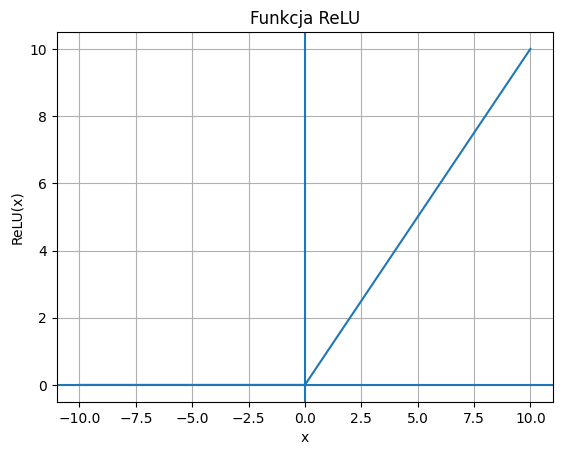

In [5]:
# ==========================================
# Rysowanie funkcji ReLU w Google Colab
# ==========================================

import numpy as np
import matplotlib.pyplot as plt

# Definicja funkcji ReLU
def relu(x):
    return np.maximum(0, x)

# Zakres wartości
x = np.linspace(-10, 10, 400)
y = relu(x)

# Rysowanie wykresu
plt.figure()
plt.plot(x, y)
plt.title("Funkcja ReLU")
plt.xlabel("x")
plt.ylabel("ReLU(x)")
plt.axhline(0)
plt.axvline(0)
plt.grid(True)

plt.show()

In [8]:
predictions = model(x_train[:1]).numpy()
predictions

array([[ 0.37261283,  0.49393278,  0.45663616,  0.7723975 , -1.0805261 ,
         0.66411984, -0.3500831 ,  0.18910852, -0.10303128, -0.716238  ]],
      dtype=float32)

In [9]:
tf.nn.softmax(predictions).numpy()

array([[0.11687295, 0.13194793, 0.12711738, 0.17431642, 0.02732901,
        0.15642779, 0.05673502, 0.097279  , 0.07263474, 0.0393398 ]],
      dtype=float32)

In [10]:
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
model.compile(optimizer='adam',
              loss=loss_fn,
              metrics=['accuracy'])

In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.fit(x_train,y_train, epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8568 - loss: 0.4933
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9536 - loss: 0.1542
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9687 - loss: 0.1078
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9730 - loss: 0.0867
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9775 - loss: 0.0724
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9804 - loss: 0.0635
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9826 - loss: 0.0568
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9840 - loss: 0.0493
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9848 - loss: 0.0461
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9855 - loss: 0.0441


In [13]:
#ocena modelu
model.evaluate(x_test, y_test, verbose=2)

313/313 - 1s - 2ms/step - accuracy: 0.9782 - loss: 0.0737


[0.07372170686721802, 0.9782000184059143]

In [14]:
probability_model = tf.keras.Sequential([
    model,
    tf.keras.layers.Softmax()
])
#

In [15]:
probability_model(x_test[:5])
#

<tf.Tensor: shape=(5, 10), dtype=float32, numpy=
array([[9.0777261e-09, 5.7725114e-12, 2.8110557e-08, 2.2058983e-05,
        5.8217230e-17, 6.0213572e-09, 2.1122639e-17, 9.9997389e-01,
        1.1240171e-09, 4.0516629e-06],
       [7.4668360e-10, 5.5183800e-06, 9.9998605e-01, 5.4531424e-06,
        2.7313546e-20, 5.4081232e-07, 8.1820218e-08, 1.6382901e-16,
        2.2977740e-06, 2.4213019e-15],
       [1.6993623e-07, 9.9796909e-01, 1.6072690e-05, 3.2965797e-06,
        6.1485166e-06, 1.2592983e-06, 1.8802270e-06, 1.8414775e-03,
        1.6036963e-04, 1.7483134e-07],
       [9.9999893e-01, 5.0411697e-12, 1.3776662e-07, 1.6919284e-10,
        3.0364010e-11, 2.9222406e-07, 1.4357451e-07, 4.3341694e-07,
        6.0853943e-12, 1.3822117e-07],
       [1.8240237e-07, 3.8411186e-14, 3.2141013e-08, 1.3418329e-10,
        9.9690241e-01, 2.5712381e-09, 1.7660094e-08, 2.7448064e-05,
        4.9359081e-09, 3.0698320e-03]], dtype=float32)>

In [16]:
import numpy as np


In [19]:
w1 = probability_model(x_test[:1])
aw = np.argmax(w1)
#

In [20]:
yw = y_test[:2]

In [21]:
aw == yw

array([ True, False])